In [ ]:
import ast
from itertools import chain
import pandas as pd
import re
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random

# SoW Action Clustering and Topic Validation

Post-processing analysis of LLM-extracted action statements from Mission Assignment Statements of Work (SoWs).

NOTE: this notebook requires the topic_exploration_env.yml environment to be set up.

In [5]:
df = pd.read_csv("actions_topics_bedrock_full_sow.csv", low_memory=False)

def parse_actions(x):
    if pd.isna(x) or x == "" or x == "[]":
        return []
    try:
        return ast.literal_eval(x)
    except:
        return []

df["clean_actions"] = df["clean_statement_actions_extracted"].apply(parse_actions)
df["sow_actions"]   = df["statementOfWork_actions_extracted"].apply(parse_actions)

df["all_actions"] = df.apply(
    lambda row: list(set(row["clean_actions"] + row["sow_actions"])),
    axis=1
)

df.head()

,incidentType,statementOfWork,clean_statement,text,clean_statement_actions_extracted,clean_statement_topic,statementOfWork_actions_extracted,statementOfWork_topic,clean_actions,sow_actions,all_actions
0,Severe Storm,"As directed by and in coordination with FEMA, ...",U.S. Geological Survey (USGS) will provide adv...,u.s. geological survey (usgs) will provide adv...,"[""Provide advance support for flood event oper...",flood monitoring and data collection,[],NaN,[Provide advance support for flood event opera...,[],[Conduct real-time field measurements of water...
1,Tropical Storm,"As directed by and in coordination with FEMA, ...",US Dept of Agriculture (USDA) will provide app...,us dept of agriculture (usda) will provide app...,"[""Provide personnel to the RRCC, IOF, JFO, or ...",personnel support,[],NaN,"[Provide personnel to the RRCC, IOF, JFO, or o...",[],"[Provide personnel to the RRCC, IOF, JFO, or o..."
2,Tropical Storm,"As directed by and in coordination with FEMA, ...",Dept of Transportation (DOT) will provide appr...,dept of transportation (dot) will provide appr...,"[""Provide appropriate personnel to RRCC, IOF, ...",personnel support,[],NaN,"[Provide appropriate personnel to RRCC, IOF, J...",[],"[Provide appropriate personnel to RRCC, IOF, J..."
3,Tropical Storm,"As directed by and in coordination with FEMA, ...",Dept of Justice (DOJ) will provide appropriate...,dept of justice (doj) will provide appropriate...,"[""Provide appropriate personnel to RRCC, JFO, ...",personnel support,[],NaN,"[Provide appropriate personnel to RRCC, JFO, I...",[],"[Provide appropriate personnel to RRCC, JFO, I..."
4,Tropical Storm,"As directed by and in coordination with FEMA, ...",Dept of Energy (DOE) will provide appropriate ...,dept of energy (doe) will provide appropriate ...,"[""Provide appropriate personnel to the RRCC, I...",energy support operations,"[""Provide personnel to the RRCC, IOF, JFO, SEO...",energy sector support,"[Provide appropriate personnel to the RRCC, IO...","[Provide personnel to the RRCC, IOF, JFO, SEOC...","[Provide appropriate personnel to the RRCC, IO..."


## Load and Parse LLM-Extracted Actions

In [6]:
all_unique_actions = sorted(set(chain.from_iterable(df["all_actions"])))
len(all_unique_actions), all_unique_actions[:20]

(22751,
 ['.S. Department of Energy (DOE) will provide 4 subject matter experts (SMEs) in electrical distribution, transmission, generation, energy efficiency, renewable energy and related topics for 4 weeks.',
  'Accelerate electric power restoration in New Jersey.',
  'Accept COVID positive patients transferred through Gallup Indian Medical Center.',
  'Accept and triage low priority medical patients.',
  'Accept non-VA patient transfers for critical and non-critical care.',
  'Accept nonhazardous materials from the State of California.',
  'Accept patient transfers coordinated by OHSU/Regional Hospital.',
  'Access resources at the Joint Field Office and Branch Offices, including tablets, printers, cameras, and fleet vehicles.',
  'Access vaccine distribution and documentation systems.',
  'Accompany Field Office (JFO) search team on site in Wisconsin.',
  'Accompany Field Office search team on site in Illinois.',
  'Accompany Field Office search team on site in Indiana.',
  'Accomp

## Action Normalization and Cleaning

Normalize actions to remove:
- State names (reduce location-specific noise)
- Numbers (reduce variation from incident IDs, counts, dates)
- Punctuation and special characters


In [7]:
def normalize_action(a):
    a = a.lower().strip()
    a = re.sub(r"[^a-z0-9\s]", "", a)
    return a

df["norm_actions"] = df["all_actions"].apply(
    lambda acts: [normalize_action(a) for a in acts]
)

print(f"Sample normalized actions: {df['norm_actions'].iloc[0][:3]}")

Sample normalized actions: ['conduct realtime field measurements of water heights', 'locate and record horizontal position and vertical elevation of high water marks', 'document high water marks with field notes digital photographs and depth measurements']


In [8]:
states = [
    "alabama","alaska","arizona","arkansas","california","colorado","connecticut",
    "delaware","florida","georgia","hawaii","idaho","illinois","indiana","iowa",
    "kansas","kentucky","louisiana","maine","maryland","massachusetts","michigan",
    "minnesota","mississippi","missouri","montana","nebraska","nevada","new hampshire",
    "new jersey","new mexico","new york","north carolina","north dakota","ohio",
    "oklahoma","oregon","pennsylvania","rhode island","south carolina","south dakota",
    "tennessee","texas","utah","vermont","virginia","washington","west virginia",
    "wisconsin","wyoming"
]

state_pattern = re.compile(r"\b(" + "|".join(states) + r")\b")

def remove_states(action):
    return state_pattern.sub("", action).strip()

df["norm_actions"] = df["norm_actions"].apply(
    lambda acts: [remove_states(a) for a in acts]
)

print("Removed state names from all actions")

Removed state names from all actions


In [9]:
def remove_numbers(a):
    return re.sub(r"\b\d+\b", "", a).strip()

df["norm_actions"] = df["norm_actions"].apply(
    lambda acts: [remove_numbers(a) for a in acts if a.strip()]
)

print("Removed numeric tokens from all actions")

Removed numeric tokens from all actions


In [10]:
# Flatten all normalized actions
unique_actions = sorted({a for acts in df["norm_actions"] for a in acts if a.strip()})
print(f"Total unique normalized actions: {len(unique_actions)}")

# Embed using sentence-transformers
model = SentenceTransformer("all-MiniLM-L6-v2")
emb = model.encode(unique_actions, convert_to_numpy=True, show_progress_bar=True)
print(f"Embeddings shape: {emb.shape}")

# cluster into 120 clusters depending on granularity
cluster = AgglomerativeClustering(n_clusters=120, linkage="average")
labels = cluster.fit_predict(emb)

action_clusters = pd.DataFrame({
    "action": unique_actions,
    "cluster": labels
})

print(f"Created {action_clusters['cluster'].nunique()} action clusters")
action_clusters.head(10)

Total unique normalized actions: 21939


Batches: 100%|██████████| 686/686 [00:21<00:00, 32.01it/s]



Embeddings shape: (21939, 384)
Created 120 action clusters
Created 120 action clusters


,action,cluster
0,accelerate electric power restoration in,6
1,accept and triage low priority medical patients,0
2,accept covid positive patients transferred thr...,13
3,accept nonhazardous materials from the state of,0
4,accept nonva patient transfers for critical an...,13
5,accept patient transfers coordinated by ohsure...,13
6,access resources at the joint field office and...,2
7,access vaccine distribution and documentation ...,13
8,accompany field office jfo search team on site in,8
9,accompany field office search team on site in,8


In [ ]:
cluster_map = dict(zip(action_clusters["action"], action_clusters["cluster"]))

df["action_cluster_ids"] = df["norm_actions"].apply(
    lambda acts: sorted({cluster_map[a] for a in acts if a in cluster_map})
)

print(f"Mapped {len(df)} SoWs to action cluster IDs")
df[["statementOfWork", "action_cluster_ids"]].head()

## Topic × Incident Type Analysis

Assign each SoW to its action cluster IDs for downstream analysis.


In [15]:
topic_incident = pd.crosstab(
    df["statementOfWork_topic"],
    df["incidentType"]
)

topic_incident_norm = topic_incident.div(topic_incident.sum(axis=1), axis=0).fillna(0)

## Creating the Heatmap

- Each row is an SoW topic
- Each column is an incident type (hurricane, flood, tornado, etc.)
- Cell color intensity = how prevalent that topic is for that incident type
- Darker blue = topic strongly associated with that incident type
- Lighter blue = topic rarely appears for that incident type

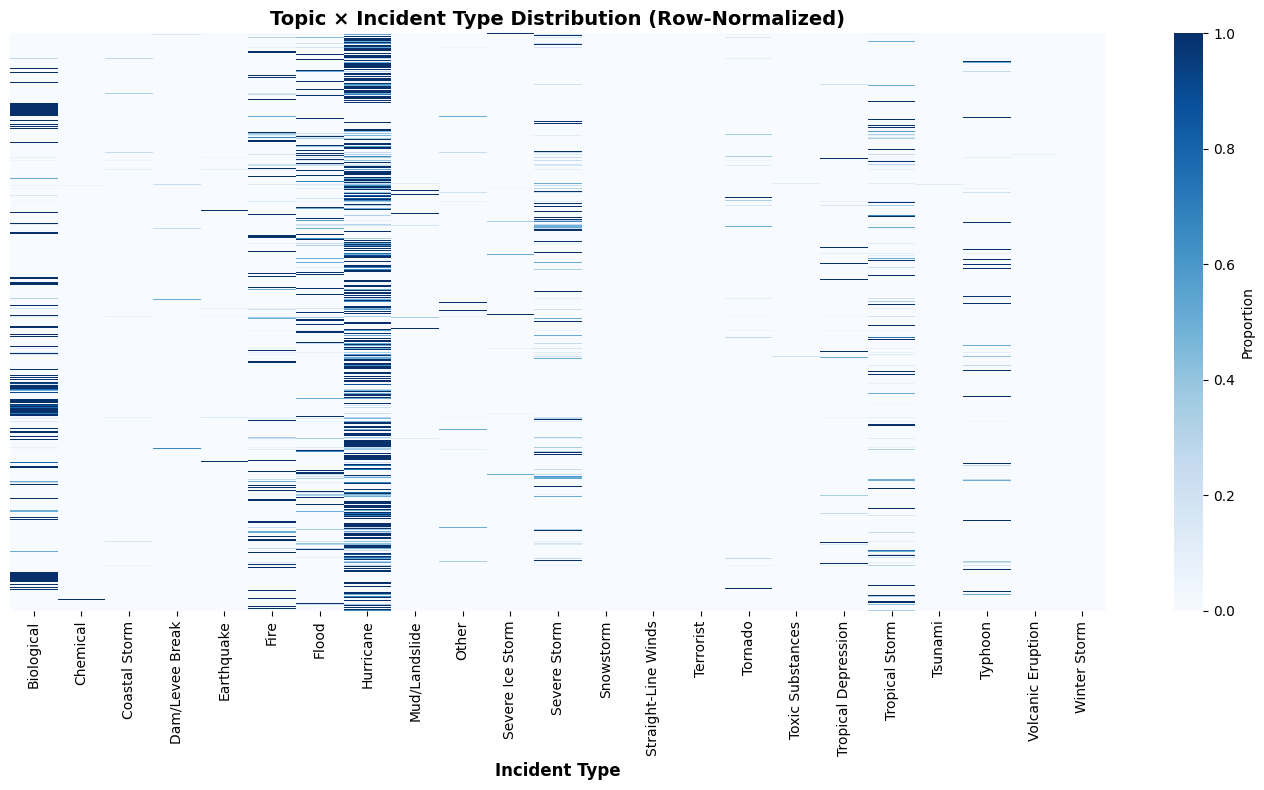

In [21]:
plt.figure(figsize=(14, 8))
sns.heatmap(topic_incident_norm, cmap="Blues", cbar_kws={"label": "Proportion"}, yticklabels=False)
plt.title("Topic × Incident Type Distribution (Row-Normalized)", fontsize=14, fontweight="bold")
plt.xlabel("Incident Type", fontsize=12, fontweight="bold")
plt.ylabel("")
plt.tight_layout()
plt.show()

add clustering to heatmap for more clasrity also remove the sow topic labels because there are too many for them to map to the rows accurately

f:\anaconda3_newest\envs\topic_exploration_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
f:\anaconda3_newest\envs\topic_exploration_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
f:\anaconda3_newest\envs\topic_exploration_env\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


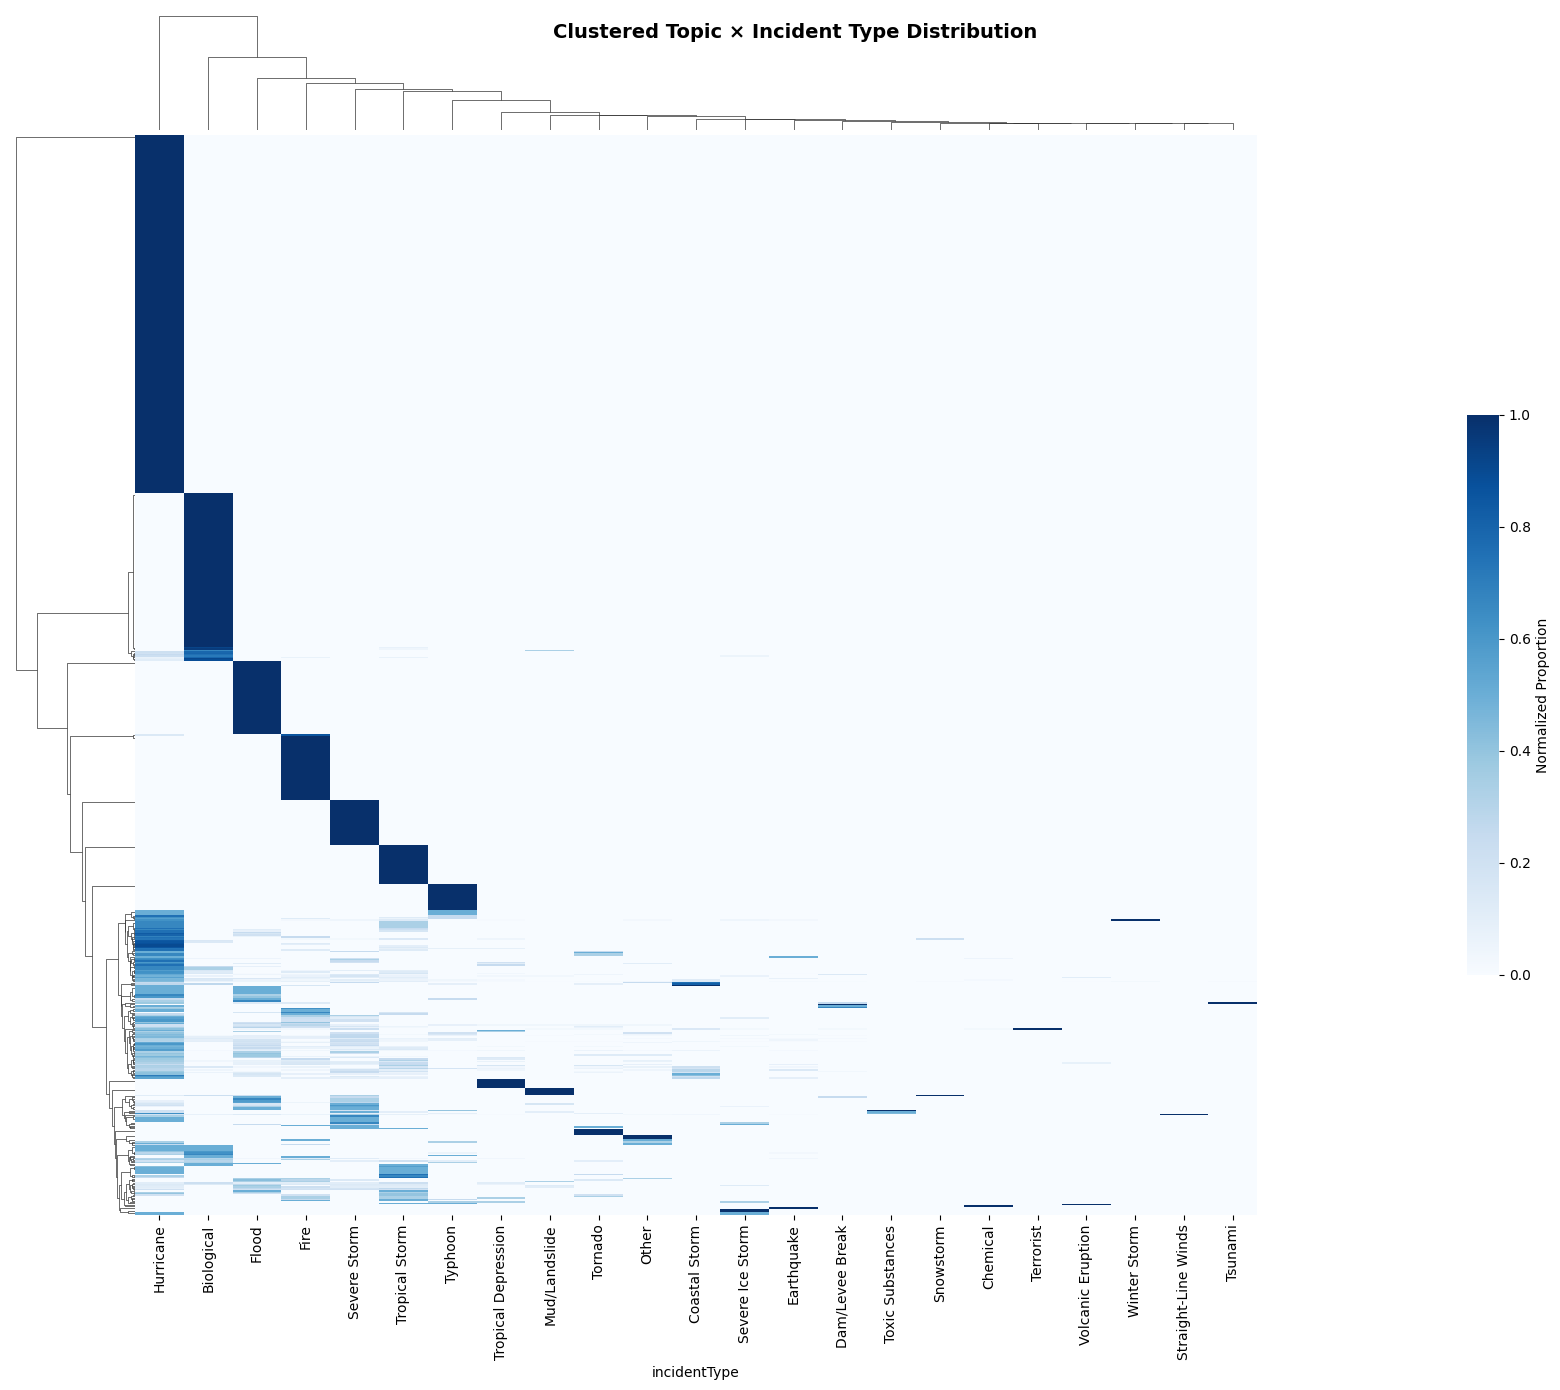

In [30]:
g = sns.clustermap(
    topic_incident_norm,
    cmap="Blues",
    figsize=(16, 14),
    metric="euclidean",
    method="ward",
    standard_scale=1,
    cbar_kws={"label": "Normalized Proportion"},
    dendrogram_ratio=0.1,
    cbar_pos=(0.92, 0.3, 0.02, 0.4)
)
g.fig.suptitle("Clustered Topic × Incident Type Distribution", fontsize=14, fontweight="bold", y=0.98)
g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_yticklabels([])
g.ax_heatmap.set_yticks([])
plt.show()

The clustering of topics and incident types reveals that while many topics are shared across multiple incident types, there are certain topics that are highly incident-specific.

## SoW Complexity Analysis

Demonstrates why simple extraction methods fail: SoWs contain highly variable numbers of actions, from minimal descriptions to complex multi-phase operations. This variability makes rule-based or simple keyword extraction unreliable.


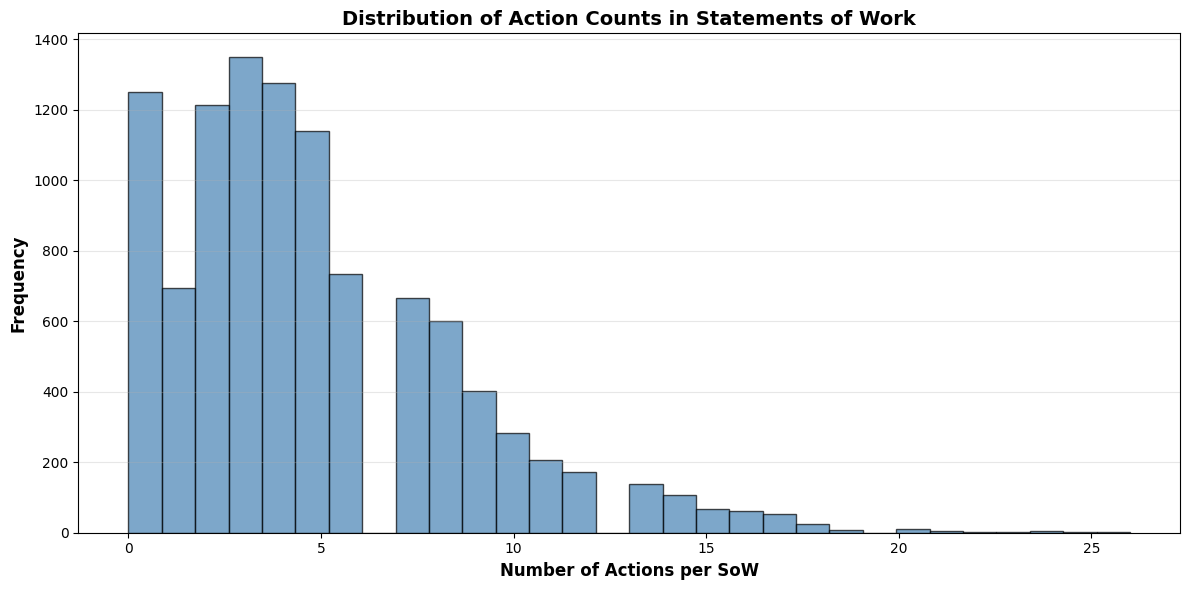

Action count statistics:
  Min: 0
  Max: 26
  Mean: 4.8
  Median: 4.0
  Std Dev: 3.8


In [33]:
df["action_count"] = df["all_actions"].apply(len)

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(df["action_count"], bins=30, color="steelblue", edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of Actions per SoW", fontsize=12, fontweight="bold")
ax.set_ylabel("Frequency", fontsize=12, fontweight="bold")
ax.set_title("Distribution of Action Counts in Statements of Work", fontsize=14, fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Action count statistics:")
print(f"  Min: {df['action_count'].min()}")
print(f"  Max: {df['action_count'].max()}")
print(f"  Mean: {df['action_count'].mean():.1f}")
print(f"  Median: {df['action_count'].median():.1f}")
print(f"  Std Dev: {df['action_count'].std():.1f}")


this histogram shows the statements of work vary in scope even after normalization. but does show why an LLM was needed to process them.

## Action Cluster Validation

Sample representative actions from semantically coherent clusters to validate that LLM extraction + embedding + clustering successfully recovered meaningful operational groupings.


In [35]:
random.seed(42)

# Find clusters with sufficient actions to sample
clusters_with_actions = action_clusters.groupby("cluster").size()
large_clusters = clusters_with_actions[clusters_with_actions >= 3].index.tolist()

# Sample 5 random clusters and display representative actions
num_samples = 5
sample_clusters = random.sample(large_clusters, min(num_samples, len(large_clusters)))

for cluster_id in sample_clusters:
    cluster_actions = action_clusters[action_clusters["cluster"] == cluster_id]["action"].tolist()
    sample_actions = random.sample(cluster_actions, min(3, len(cluster_actions)))
    
    print(f"Cluster {cluster_id} (n={len(cluster_actions)} actions)")
    for i, action in enumerate(sample_actions, 1):
        print(f"  {i}. {action}")


Cluster 92 (n=11 actions)
  1. conduct pallet building 463l
  2. supply cots to richmond county
  3. build pallets using 463l standard
Cluster 14 (n=330 actions)
  1. coordinate usace and fema external affairs messaging
  2. share information and guidance on sustainability considerations
  3. coordinate external affairs messaging activities
Cluster 3 (n=470 actions)
  1. provide aerial imagery of the affected area in support of damage assessment and response operations
  2. hand deliver images on digital media as directed
  3. capture aerialground imaging including video still photography and 2d3d data
Cluster 109 (n=8 actions)
  1. deploy  bilingual spanishenglish service members to support engineering signal and other operations
  2. provide personnel who can speak afghan language dialect to support vaccine mission and assist with translations and instructions
  3. deploy  soldiers to assist with translation or transcription
Cluster 36 (n=10 actions)
  1. coordinate rsapod operations

while many of the clusters are broad there are several that are extremely specific. This is to be expected given the wide variety of tasks FEMA SoWs cover. It is also worth nothing that one of these example clusters still has a location specific action even after normalization which shows the difficulty of the task and that some noise will always be present, but we could probably improve the normalization step further to remove these outliers in the future.